# 📊 Lab: Data Preparation, Clustering & Classification
**Course:** ESPRIT — 4CCE9 (2026–2027)  
**Dataset:** Adult Census Income (UCI Machine Learning Repository)  
**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Target Variable:** `income` (`<=50K` vs `>50K`)

---

## 1. Business Understanding

### 1.1 Context & Problem Formulation
Predicting an individual's earning capacity based on demographic, occupational, and educational parameters is a core problem in computational economics, financial credit scoring, and government policy planning. The **Adult Census Income dataset** (extracted from the 1994 U.S. Census Bureau database by Ronny Kohavi & Barry Becker) frames this as a binary classification challenge:
> **Objective:** Predict whether an individual's annual income exceeds $50,000.
 
### 1.2 Practical Business Applications
1. **Credit Risk & Loan Pre-Approval:** Allows automated financial underwriting without requiring immediate tax audit disclosures.
2. **Public Policy & Wage Disparity Research:** Dissects the quantitative relationship between education, working hours, demographic factors, and income thresholds.
3. **Targeted Wealth Marketing:** Enables institutions to direct wealth management and premium services to high-earning brackets.

### 1.3 Asymmetric Error Costs & Metric Justification
- **False Positive (Type I Error):** Model predicts `>50K`, but the true income is `<=50K`. (Consequence: Granting a loan or credit limit beyond the applicant's repayment ability $\rightarrow$ high default risk).
- **False Negative (Type II Error):** Model predicts `<=50K`, but the true income is `>50K`. (Consequence: Sub-optimal marketing targeting / minor lost opportunity).
- **Metric Choice:** Because the dataset has ~76% `<=50K` and ~24% `>50K`, standard **Accuracy is misleading** (a naive model predicting `<=50K` for everyone achieves ~76% accuracy while catching 0% of high earners). We prioritize **ROC-AUC, Precision-Recall AUC (PR-AUC), and F1-Score**.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, roc_auc_score, f1_score, precision_score, 
    recall_score, accuracy_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ All required libraries imported successfully!")


✅ All required libraries imported successfully!


---
## 2. Data Understanding & Acquisition

We load both the training split (`adult.data`, 32,561 rows) and test split (`adult.test`, 16,281 rows).
**Key Considerations:**
- Column headers are missing in the raw text and must be assigned from `adult.names`.
- Leading whitespace after commas must be stripped (`skipinitialspace=True`).
- Line 1 of `adult.test` contains a cross-validation comment (`|1x3 Cross validator`), requiring `skiprows=1`.


In [5]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train_path = '../data/raw/adult.data'
test_path  = '../data/raw/adult.test'

# Load raw splits
df_train = pd.read_csv(train_path, header=None, names=columns, skipinitialspace=True)
df_test  = pd.read_csv(test_path,  header=None, names=columns, skipinitialspace=True, skiprows=1)

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape:     {df_test.shape}")
print(f"Total observations: {len(df_train) + len(df_test)}")

df_train.head()


Training set shape: (32561, 15)
Test set shape:     (16281, 15)
Total observations: 48842


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---
### 2.1 Unmasking Data Quality Issues & Traps

We immediately inspect:
1. **Target String Inconsistency:** Note that UCI added a trailing dot `.` to labels in `adult.test` (`<=50K.` vs `<=50K`).
2. **Hidden Missing Values (`?`):** Missing entries were encoded as literal `'?'` characters, escaping standard `.isnull()` checks.
3. **Exact Duplicates:** Identifying identical participant responses.


In [6]:
# 1. Target Label Comparison
print("=== TARGET VALUE COUNTS (Train) ===")
print(df_train['income'].value_counts())
print("\n=== TARGET VALUE COUNTS (Test) ===")
print(df_test['income'].value_counts())

# 2. Inspecting Hidden Missing Values ('?')
print("\n=== FEATURES WITH '?' ENCODED VALUES (Train) ===")
missing_stats = []
for col in df_train.columns:
    q_count = (df_train[col] == '?').sum()
    if q_count > 0:
        missing_stats.append({
            'Feature': col,
            'Missing_Count': q_count,
            'Percentage': round((q_count / len(df_train)) * 100, 2)
        })

df_missing = pd.DataFrame(missing_stats)
display(df_missing)

# 3. Duplicate Records
print(f"\nDuplicate rows in Train: {df_train.duplicated().sum()}")
print(f"Duplicate rows in Test:  {df_test.duplicated().sum()}")


=== TARGET VALUE COUNTS (Train) ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

=== TARGET VALUE COUNTS (Test) ===
income
<=50K.    12435
>50K.      3846
Name: count, dtype: int64

=== FEATURES WITH '?' ENCODED VALUES (Train) ===


,Feature,Missing_Count,Percentage
0,workclass,1836,5.64
1,occupation,1843,5.66
2,native_country,583,1.79



Duplicate rows in Train: 24
Duplicate rows in Test:  5


---
## 3. Exploratory Data Analysis (EDA) & Visualizations

We now systematically analyze:
- **Target Distribution & Imbalance**
- **Age Distribution by Income Level**
- **Education Level & Educational Attainment (`education_num`) vs Income**
- **Working Hours (`hours_per_week`) vs Income**
- **Extreme Skewness in `capital_gain` and `capital_loss`**


C:\Users\mehdi\AppData\Local\Temp\ipykernel_21744\797889661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='income', ax=axes[0], palette=['#4A90E2', '#E74C3C'])


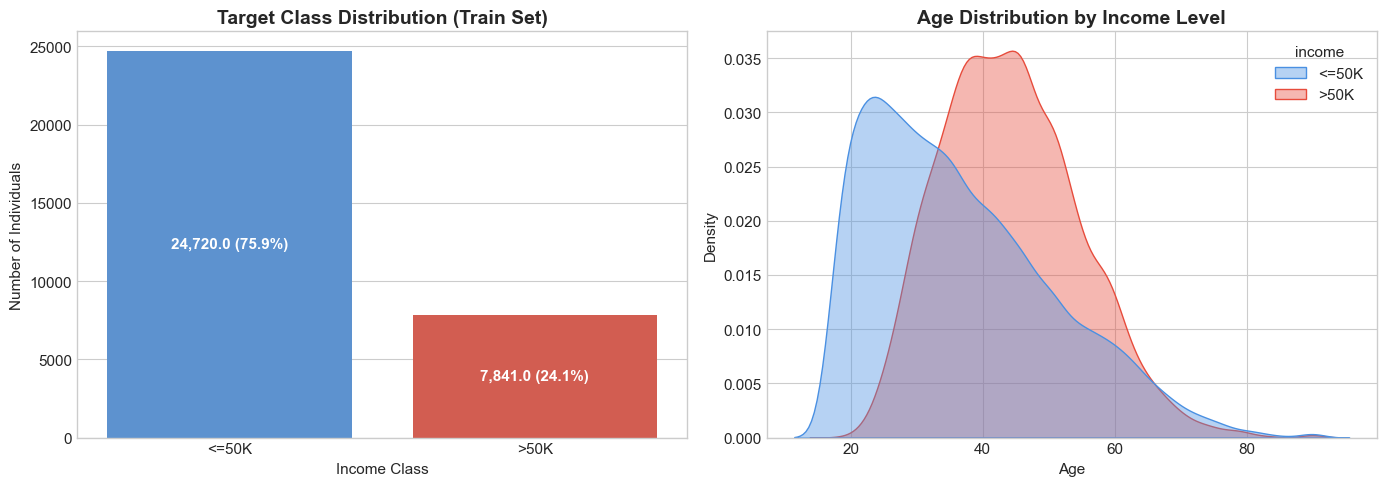

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Class Imbalance
sns.countplot(data=df_train, x='income', ax=axes[0], palette=['#4A90E2', '#E74C3C'])
axes[0].set_title('Target Class Distribution (Train Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Income Class')
axes[0].set_ylabel('Number of Individuals')
total = len(df_train)
for p in axes[0].patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(f"{p.get_height():,} ({pct})", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Plot 2: Age vs Income KDE
sns.kdeplot(data=df_train, x='age', hue='income', common_norm=False, fill=True, ax=axes[1], palette=['#4A90E2', '#E74C3C'], alpha=0.4)
axes[1].set_title('Age Distribution by Income Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


C:\Users\mehdi\AppData\Local\Temp\ipykernel_21744\321156976.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='income', y='hours_per_week', ax=axes[1], palette=['#4A90E2', '#E74C3C'])


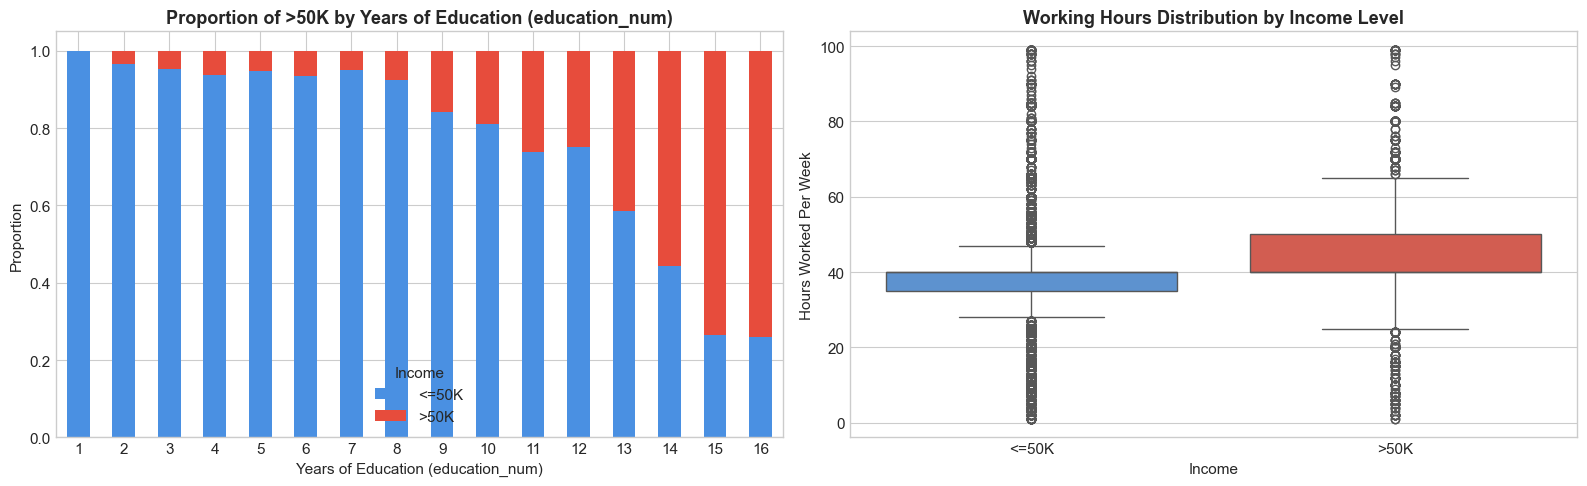

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: Education Years vs Income Proportion
edu_income = pd.crosstab(df_train['education_num'], df_train['income'], normalize='index')
edu_income.plot(kind='bar', stacked=True, ax=axes[0], color=['#4A90E2', '#E74C3C'])
axes[0].set_title('Proportion of >50K by Years of Education (education_num)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Years of Education (education_num)')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Income')
axes[0].tick_params(axis='x', rotation=0)

# Plot 4: Hours Per Week vs Income
sns.boxplot(data=df_train, x='income', y='hours_per_week', ax=axes[1], palette=['#4A90E2', '#E74C3C'])
axes[1].set_title('Working Hours Distribution by Income Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Hours Worked Per Week')

plt.tight_layout()
plt.show()


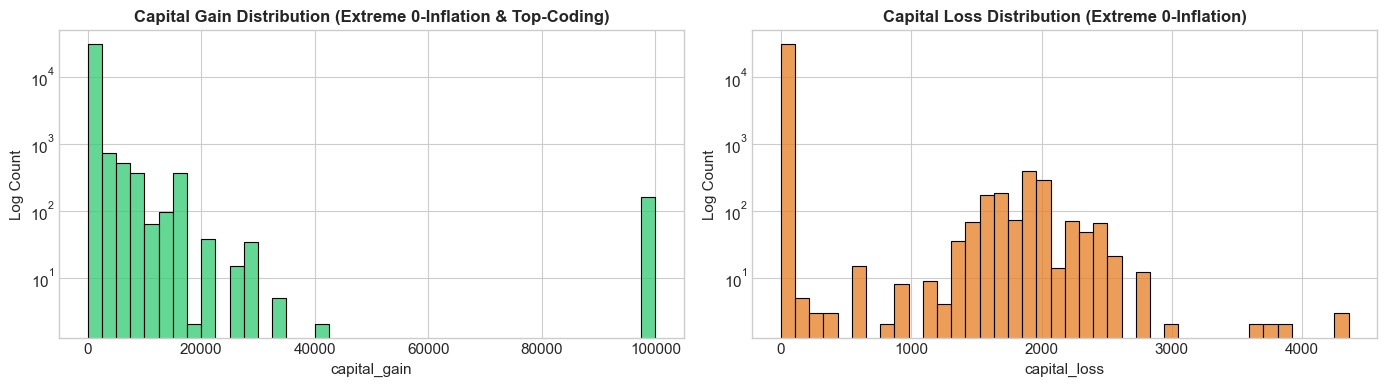

Capital Gain Skewness: 11.95
Capital Loss Skewness: 4.59
Percentage of 0s in capital_gain: 91.67%
Percentage of 0s in capital_loss: 95.33%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Capital Gain Distribution
sns.histplot(df_train['capital_gain'], bins=40, kde=False, ax=axes[0], color='#2ECC71')
axes[0].set_title('Capital Gain Distribution (Extreme 0-Inflation & Top-Coding)', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Log Count')

# Capital Loss Distribution
sns.histplot(df_train['capital_loss'], bins=40, kde=False, ax=axes[1], color='#E67E22')
axes[1].set_title('Capital Loss Distribution (Extreme 0-Inflation)', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_ylabel('Log Count')

plt.tight_layout()
plt.show()

print(f"Capital Gain Skewness: {df_train['capital_gain'].skew():.2f}")
print(f"Capital Loss Skewness: {df_train['capital_loss'].skew():.2f}")
print(f"Percentage of 0s in capital_gain: {(df_train['capital_gain'] == 0).mean() * 100:.2f}%")
print(f"Percentage of 0s in capital_loss: {(df_train['capital_loss'] == 0).mean() * 100:.2f}%")


---
### 3.1 Key Observations from EDA (For Report & Slides)
1. **Class Imbalance:** 75.9% of workers earn $\le$50K, while only 24.1% earn >50K. 
2. **Age Dynamics:** Higher earners have a peak distribution between ages 35 and 52, whereas lower earners are heavily concentrated among younger workers (<30).
3. **Education Threshold Effect:** High-earning probability accelerates sharply after 12 years of education (`education_num` $\ge$ 13 corresponds to Bachelor's, Master's, Doctorate).
4. **Hours Per Week Outliers:** The standard work week is 40 hours, but significant outliers work up to 99 hours or as low as 1 hour.
5. **Zero-Inflation in Capital Gains/Losses:** Over 91.7% of entries have 0 capital gains, and 95.3% have 0 capital losses. Furthermore, `capital_gain` is top-coded at $99,999.
6. **Redundancy:** `education` and `education_num` represent the identical underlying metric, requiring removal of one to prevent multicollinearity.


---
## 4. Data Preparation & Feature Engineering Pipeline

### 4.1 Methodological Justifications

| Step | Technique | Methodological Justification |
| :--- | :--- | :--- |
| **Target Standardization** | Strip trailing `.` and binarize (`0` for `<=50K`, `1` for `>50K`). | Resolves format divergence between train and test splits. |
| **Missing Value Handling** | Impute `'Unknown'` category for `workclass`, `occupation`, and `native_country`. | Preserves all rows without data loss. Missingness in occupation/workclass often signifies informal or non-standard employment; preserving it as an explicit category maintains this informative signal. |
| **Redundancy & Noise Removal** | Drop `education` and `fnlwgt`. | `education` is collinear with `education_num`. `fnlwgt` is a demographic survey sampling weight with zero intrinsic socioeconomic predictive power. |
| **High-Cardinality Binning** | Regroup `native_country` (into 5 regions), `marital_status` (into 4 tiers), and `workclass` (into 4 sectors). | `native_country` had 42 categories where 89.6% was US. Binning mitigates sparse feature matrices and avoids the curse of dimensionality. |
| **Nonlinear Feature Engineering** | Create `net_capital`, `log_capital_gain`, `log_capital_loss`, `has_capital_gain`, `is_overtime`, `hours_category`, `age_group`. | Captures nonlinear interactions, log-transforms right-skewed monetary features, and models labor hour thresholds. |
| **Feature Scaling** | `RobustScaler` on numerical features. | Unlike `StandardScaler`, `RobustScaler` scales based on the Median and Interquartile Range (IQR), preventing the remaining heavy tails from distorting distance-based models. |


In [16]:
# 1. Clean Target Variable
df_train['income'] = df_train['income'].str.rstrip('.')
df_test['income']  = df_test['income'].str.rstrip('.')

y_train = (df_train['income'] == '>50K').astype(int)
y_test  = (df_test['income'] == '>50K').astype(int)

# 2. Comprehensive Preprocessing & Feature Engineering Function
def preprocess_census_data(df):
    df = df.copy()
    
    # Impute missing values with explicit category
    df['workclass'] = df['workclass'].replace('?', 'Unknown')
    df['occupation'] = df['occupation'].replace('?', 'Unknown')
    df['native_country'] = df['native_country'].replace('?', 'Unknown')
    
    # Marital status consolidation
    marital_map = {
        'Married-civ-spouse': 'Married',
        'Married-AF-spouse': 'Married',
        'Married-spouse-absent': 'Separated_Divorced',
        'Divorced': 'Separated_Divorced',
        'Separated': 'Separated_Divorced',
        'Widowed': 'Widowed',
        'Never-married': 'Never_Married'
    }
    df['marital_group'] = df['marital_status'].map(marital_map).fillna('Other')
    
    # Native country consolidation
    def map_country(country):
        if country == 'United-States':
            return 'United_States'
        elif country in ['Mexico', 'Puerto-Rico', 'Cuba', 'Jamaica', 'Dominican-Republic', 
                         'Guatemala', 'El-Salvador', 'Columbia', 'Haiti', 'Nicaragua', 
                         'Peru', 'Ecuador', 'Trinadad&Tobago', 'Honduras']:
            return 'Latin_America_Caribbean'
        elif country in ['Philippines', 'India', 'China', 'Japan', 'Vietnam', 
                         'Taiwan', 'Iran', 'Hong', 'Thailand', 'Cambodia', 'Laos']:
            return 'Asia'
        elif country in ['Germany', 'England', 'Italy', 'Poland', 'Portugal', 
                         'Greece', 'Ireland', 'France', 'Yugoslavia', 'Scotland', 
                         'Hungary', 'Holand-Netherlands']:
            return 'Europe'
        else:
            return 'Other_Region'
            
    df['region'] = df['native_country'].apply(map_country)
    
    # Workclass consolidation
    def map_workclass(wc):
        if wc in ['Federal-gov', 'Local-gov', 'State-gov']:
            return 'Government'
        elif wc in ['Self-emp-inc', 'Self-emp-not-inc']:
            return 'Self_Employed'
        elif wc == 'Private':
            return 'Private'
        else:
            return 'Other_Unknown'
    df['workclass_group'] = df['workclass'].apply(map_workclass)
    
    # Feature Engineering
    df['net_capital'] = df['capital_gain'] - df['capital_loss']
    df['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
    df['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)
    df['log_capital_gain'] = np.log1p(df['capital_gain'])
    df['log_capital_loss'] = np.log1p(df['capital_loss'])
    
    df['is_overtime'] = (df['hours_per_week'] > 40).astype(int)
    df['hours_category'] = pd.cut(
        df['hours_per_week'], 
        bins=[0, 34, 40, 50, 100], 
        labels=['Part_Time', 'Full_Time', 'Overtime', 'Extreme_Hours']
    ).astype(str)
    
    df['age_group'] = pd.cut(
        df['age'], 
        bins=[16, 25, 45, 65, 100], 
        labels=['Young', 'Prime_Career', 'Mature_Career', 'Senior']
    ).astype(str)
    
    # Drop redundant, noisy, and raw consolidated features
    drop_cols = ['education', 'fnlwgt', 'marital_status', 'native_country', 'workclass', 'income']
    df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    return df_clean

# Transform raw splits
X_train_raw = preprocess_census_data(df_train)
X_test_raw  = preprocess_census_data(df_test)

print(f"Preprocessed Train shape: {X_train_raw.shape}")
print(f"Preprocessed Test shape:  {X_test_raw.shape}")
X_train_raw.head(3)


Preprocessed Train shape: (32561, 20)
Preprocessed Test shape:  (16281, 20)


,age,education_num,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,marital_group,region,workclass_group,net_capital,has_capital_gain,has_capital_loss,log_capital_gain,log_capital_loss,is_overtime,hours_category,age_group
0,39,13,Adm-clerical,Not-in-family,White,Male,2174,0,40,Never_Married,United_States,Government,2174,1,0,7.684784,0.0,0,Full_Time,Prime_Career
1,50,13,Exec-managerial,Husband,White,Male,0,0,13,Married,United_States,Self_Employed,0,0,0,0.000000,0.0,0,Part_Time,Mature_Career
2,38,9,Handlers-cleaners,Not-in-family,White,Male,0,0,40,Separated_Divorced,United_States,Private,0,0,0,0.000000,0.0,0,Full_Time,Prime_Career


In [17]:
# 3. Categorical One-Hot Encoding with Strict Train-Test Alignment
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()

X_train_encoded = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True, dtype=int)
X_test_encoded  = pd.get_dummies(X_test_raw,  columns=cat_cols, drop_first=True, dtype=int)

# Align columns to prevent train/test feature mismatch
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 4. Numerical Scaling via RobustScaler (fitted ONLY on train to avoid data leakage)
num_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 
            'net_capital', 'log_capital_gain', 'log_capital_loss']

scaler = RobustScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled  = X_test_encoded.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_encoded[num_cols])

print(f"✅ Final Processed Train Matrix: {X_train_scaled.shape}")
print(f"✅ Final Processed Test Matrix:  {X_test_scaled.shape}")

# 5. Export Deliverables: Cleaned & Transformed Datasets
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

train_export = X_train_scaled.copy()
train_export['income_target'] = y_train
test_export = X_test_scaled.copy()
test_export['income_target'] = y_test

train_export.to_csv(os.path.join(processed_dir, 'adult_cleaned_train.csv'), index=False)
test_export.to_csv(os.path.join(processed_dir, 'adult_cleaned_test.csv'), index=False)

print(f"💾 Successfully saved 'adult_cleaned_train.csv' ({len(train_export)} rows)")
print(f"💾 Successfully saved 'adult_cleaned_test.csv'  ({len(test_export)} rows)")


✅ Final Processed Train Matrix: (32561, 51)
✅ Final Processed Test Matrix:  (16281, 51)
💾 Successfully saved 'adult_cleaned_train.csv' (32561 rows)
💾 Successfully saved 'adult_cleaned_test.csv'  (16281 rows)
